<a href="https://colab.research.google.com/github/pratcode11/CCLab3/blob/main/ChestXRay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip
!unzip master.zip


--2025-04-07 06:57:01--  https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/ieee8023/covid-chestxray-dataset/zip/refs/heads/master [following]
--2025-04-07 06:57:01--  https://codeload.github.com/ieee8023/covid-chestxray-dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.114.9
Connecting to codeload.github.com (codeload.github.com)|140.82.114.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘master.zip’

master.zip              [             <=>    ] 525.03M  32.8MB/s    in 24s     

2025-04-07 06:57:25 (21.8 MB/s) - ‘master.zip’ saved [550535079]

Archive:  master.zip
78543292f8b01d5e0ed1d0e15dce71949f0657bb
   creating: covid-chestxray-datase

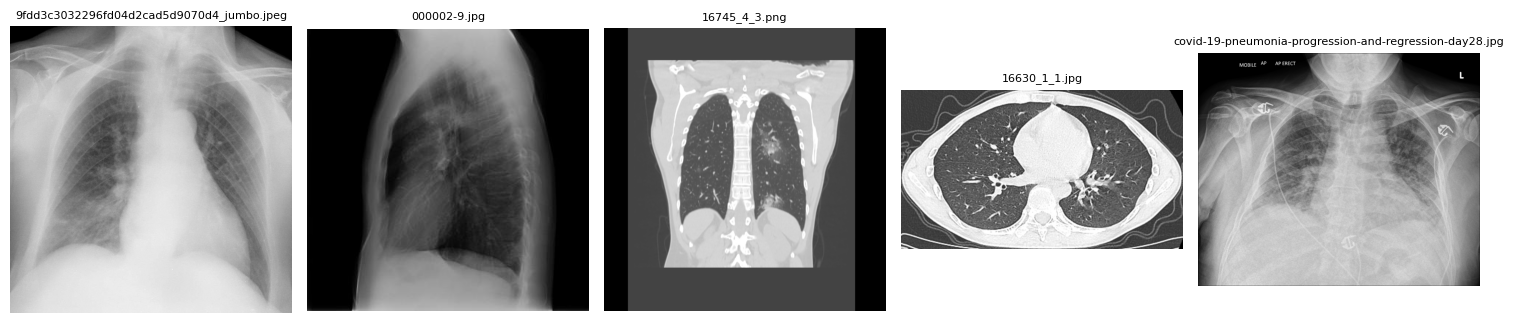

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the image folder
img_folder = 'covid-chestxray-dataset-master/images/'

# List image files (limit to first 5 for demo)
image_files = [f for f in os.listdir(img_folder) if f.endswith(('.png', '.jpg', '.jpeg'))][:5]

# Plot the images
plt.figure(figsize=(15, 8))
for i, img_name in enumerate(image_files):
    img_path = os.path.join(img_folder, img_name)
    img = mpimg.imread(img_path)
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(img_name, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

df = pd.read_csv('covid-chestxray-dataset-master/metadata.csv')
print(df['finding'].value_counts())


finding
Pneumonia/Viral/COVID-19                   584
todo                                        83
Pneumonia                                   81
Pneumonia/Fungal/Pneumocystis               30
Pneumonia/Bacterial/Streptococcus           22
No Finding                                  22
Tuberculosis                                18
Pneumonia/Viral/SARS                        16
Pneumonia/Lipoid                            13
Pneumonia/Bacterial/Mycoplasma              11
Pneumonia/Viral/MERS-CoV                    10
Pneumonia/Bacterial/Klebsiella              10
Pneumonia/Bacterial/Legionella              10
Pneumonia/Bacterial/Nocardia                 8
Pneumonia/Viral/Varicella                    6
Pneumonia/Viral/Influenza                    5
Pneumonia/Bacterial/E.Coli                   4
Pneumonia/Bacterial                          4
Pneumonia/Bacterial/Chlamydophila            3
Pneumonia/Viral/Herpes                       3
Pneumonia/Fungal/Aspergillosis               2
Pneum

In [ ]:
import os

os.makedirs('data/COVID', exist_ok=True)
os.makedirs('data/Non-COVID', exist_ok=True)


In [ ]:
import pandas as pd
import shutil

df = pd.read_csv('covid-chestxray-dataset-master/metadata.csv')
image_dir = 'covid-chestxray-dataset-master/images/'

for _, row in df.iterrows():
    filename = row['filename']
    finding = row['finding']
    src = os.path.join(image_dir, filename)

    if not os.path.exists(src):
        continue  # Skip if image doesn't exist

    # Binary classification: COVID vs Non-COVID
    if finding == 'Pneumonia/Viral/COVID-19':
        shutil.copy(src, 'data/COVID/')
    else:
        shutil.copy(src, 'data/Non-COVID/')


In [ ]:
import os

covid_count = len(os.listdir('data/COVID'))
noncovid_count = len(os.listdir('data/Non-COVID'))

print(f'COVID images: {covid_count}')
print(f'Non-COVID images: {noncovid_count}')


COVID images: 563
Non-COVID images: 366


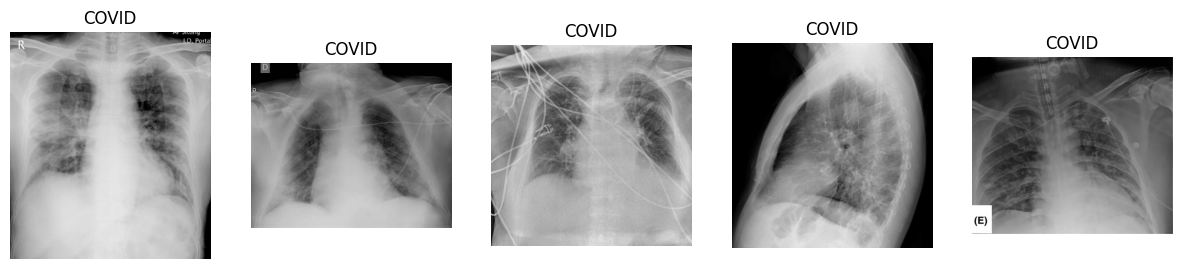

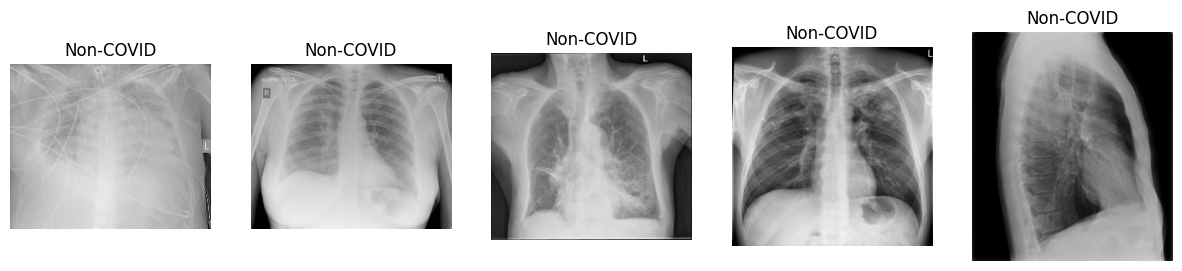

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def show_sample_images(folder_path, label, num_images=5):
    images = os.listdir(folder_path)
    selected_images = random.sample(images, min(num_images, len(images)))

    plt.figure(figsize=(15, 5))
    for i, image_name in enumerate(selected_images):
        img_path = os.path.join(folder_path, image_name)
        img = mpimg.imread(img_path)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')
    plt.show()

# Show samples from each class
show_sample_images('data/COVID', 'COVID')
show_sample_images('data/Non-COVID', 'Non-COVID')


In [ ]:
!pip install tensorflow-addons


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.2
    Uninstalling typeguard-4.4.2:
      Successfully uninstalled typeguard-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# === Custom Focal Loss ===
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_mean(alpha * tf.math.pow(1. - pt_1, gamma) * tf.math.log(pt_1 + epsilon) +
                               (1 - alpha) * tf.math.pow(pt_0, gamma) * tf.math.log(1. - pt_0 + epsilon))
    return focal_loss_fixed

# === Data Prep ===
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

train_gen = datagen.flow_from_directory(
    'data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    color_mode='rgb',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    'data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    color_mode='rgb',
    shuffle=False
)

# === Model ===
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False  # Freeze base initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# === Initial Compile & Train ===
model.compile(
    optimizer='adam',
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

# === Unfreeze & Fine-tune ===
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model_resnet50_focal.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)


Found 744 images belonging to 2 classes.
Found 185 images belonging to 2 classes.
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_1086']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


24/24 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.5427 - auc: 0.4510 - loss: 0.1097 - val_accuracy: 0.6054 - val_auc: 0.5363 - val_loss: 0.0700
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5949 - auc: 0.4982 - loss: 0.0773 - val_accuracy: 0.6054 - val_auc: 0.4773 - val_loss: 0.0677
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6101 - auc: 0.5390 - loss: 0.0703 - val_accuracy: 0.6054 - val_auc: 0.4687 - val_loss: 0.0675
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6204 - auc: 0.4684 - loss: 0.0730 - val_accuracy: 0.6054 - val_auc: 0.4714 - val_loss: 0.0673
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6027 - auc: 0.5109 - loss: 0.0712 - val_accuracy: 0.6054 - val_auc: 0.4756 - val_loss: 0.0684
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.6173 - auc: 0.4853 - loss: 0.1380 - val_accuracy: 0.6054 - val_auc: 0.4532 - val_loss: 0.0703 - learning_rate: 1.0000e-05
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 33

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

# === Custom Focal Loss ===
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_mean(alpha * tf.math.pow(1. - pt_1, gamma) * tf.math.log(pt_1 + epsilon) +
                               (1 - alpha) * tf.math.pow(pt_0, gamma) * tf.math.log(1. - pt_0 + epsilon))
    return focal_loss_fixed

# === Data Prep ===
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

train_gen = datagen.flow_from_directory(
    'data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    color_mode='rgb',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    'data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    color_mode='rgb',
    shuffle=False
)

# === Model ===
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False  # Freeze base initially

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# === Initial Compile & Train ===
model.compile(
    optimizer='adam',
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)

# === Unfreeze & Fine-tune ===
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

# === Callbacks ===
callbacks = [
    EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint('best_model_resnet50_focal.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# === Plot AUC ===
plt.plot(history_fine.history['auc'], label='Train AUC')
plt.plot(history_fine.history['val_auc'], label='Val AUC')
plt.title('AUC Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


Found 744 images belonging to 2 classes.
Found 185 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


24/24 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.5745 - auc: 0.5174 - loss: 0.1021 - val_accuracy: 0.6054 - val_auc: 0.4555 - val_loss: 0.0678
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5832 - auc: 0.5425 - loss: 0.0736 - val_accuracy: 0.6054 - val_auc: 0.4936 - val_loss: 0.0719
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5958 - auc: 0.5296 - loss: 0.0716 - val_accuracy: 0.6054 - val_auc: 0.4481 - val_loss: 0.0676
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6106 - auc: 0.4633 - loss: 0.0731 - val_accuracy: 0.6054 - val_auc: 0.4946 - val_loss: 0.0696
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6187 - auc: 0.4967 - loss: 0.0701 - val_accuracy: 0.6054 - val_auc: 0.4544 - val_loss: 0.0683
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6279 - auc: 0.4577 - loss: 0.1524
Epoch 1: val_auc improved from -inf to 0.55963, saving model to best_model_resnet50_focal.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 130s 

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

# === Optional Focal Loss ===
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_mean(
            alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1 + epsilon) +
            (1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0 + epsilon)
        )
    return focal_loss_fixed

# === Parameters ===
use_focal_loss = False     # 👈 Set to True to use focal loss
input_shape = (224, 224, 3)
batch_size = 32
epochs_initial = 5
epochs_finetune = 5
data_path = 'data'  # Folder with subdirs for each class

# === Data Generators ===
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_gen = datagen.flow_from_directory(
    data_path,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    color_mode='rgb',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_path,
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    color_mode='rgb',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

# === Model Architecture ===
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=input_shape))
base_model.trainable = False  # Freeze for initial training

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# === Compile Initial Model ===
loss_function = focal_loss(gamma=2., alpha=0.25) if use_focal_loss else 'binary_crossentropy'

model.compile(
    optimizer='adam',
    loss=loss_function,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# === Train (Frozen ResNet50) ===
history_initial = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs_initial
)

# === Unfreeze Base Model for Fine-tuning ===
base_model.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_function,
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

# === Fine-tune ===
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs_finetune,
    callbacks=callbacks
)

# === Save Final Model ===
model.save('resnet50_binary_final.h5')


Found 744 images belonging to 2 classes.
Found 185 images belonging to 2 classes.
Class indices: {'COVID': 0, 'Non-COVID': 1}
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_181']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


24/24 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.5490 - auc: 0.5159 - loss: 0.7519 - val_accuracy: 0.6054 - val_auc: 0.4370 - val_loss: 0.6674
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5727 - auc: 0.5026 - loss: 0.6982 - val_accuracy: 0.6054 - val_auc: 0.4418 - val_loss: 0.6690
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5718 - auc: 0.5056 - loss: 0.6834 - val_accuracy: 0.6054 - val_auc: 0.4455 - val_loss: 0.6690
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5895 - auc: 0.5148 - loss: 0.6830 - val_accuracy: 0.6054 - val_auc: 0.4240 - val_loss: 0.6656
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5854 - auc: 0.5460 - loss: 0.6708 - val_accuracy: 0.6054 - val_auc: 0.4347 - val_loss: 0.6660
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.5998 - auc: 0.5144 - loss: 1.1333 - val_accuracy: 0.6054 - val_auc: 0.4323 - val_loss: 0.6678 - learning_rate: 1.0000e-05
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 32

In [ ]:
import os
from collections import Counter
print(Counter(train_gen.classes))


Counter({np.int32(0): 451, np.int32(1): 293})


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

# Map into dictionary
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(0.8248337028824834), 1: np.float64(1.2696245733788396)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils import class_weight
import numpy as np

# === Custom Focal Loss ===
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_mean(alpha * tf.math.pow(1. - pt_1, gamma) * tf.math.log(pt_1 + epsilon) +
                               (1 - alpha) * tf.math.pow(pt_0, gamma) * tf.math.log(1. - pt_0 + epsilon))
    return focal_loss_fixed

# === Data Prep ===
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.3,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

train_gen = datagen.flow_from_directory(
    'data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    color_mode='rgb',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    'data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    color_mode='rgb',
    shuffle=False
)

# === Compute Class Weights ===
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

# === Build Model ===
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# === Compile & Train (Initial Frozen Phase) ===
model.compile(
    optimizer='adam',
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weight_dict
)

# === Unfreeze & Fine-tune ===
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2., alpha=0.25),
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model_resnet50_focal.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1)
]

model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)


Found 744 images belonging to 2 classes.
Found 185 images belonging to 2 classes.
Class Weights: {0: np.float64(0.8248337028824834), 1: np.float64(1.2696245733788396)}


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_362']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


24/24 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.5516 - auc: 0.5086 - loss: 0.1024 - val_accuracy: 0.6054 - val_auc: 0.4925 - val_loss: 0.0717
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.6059 - auc: 0.4171 - loss: 0.0773 - val_accuracy: 0.6054 - val_auc: 0.4336 - val_loss: 0.0744
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5997 - auc: 0.4968 - loss: 0.0735 - val_accuracy: 0.6054 - val_auc: 0.4969 - val_loss: 0.0687
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6070 - auc: 0.4803 - loss: 0.0723 - val_accuracy: 0.6054 - val_auc: 0.4652 - val_loss: 0.0678
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5965 - auc: 0.4913 - loss: 0.0719 - val_accuracy: 0.6054 - val_auc: 0.4757 - val_loss: 0.0670
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 120s 3s/step - accuracy: 0.6021 - auc: 0.5263 - loss: 0.2125 - val_accuracy: 0.6054 - val_auc: 0.5134 - val_loss: 0.0688 - learning_rate: 1.0000e-05
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 